In [1]:
%load_ext autoreload
%autoreload 2

In [14]:
import numpy as np
import pandas as pd
import time
import scipy.stats as spst
import scipy.special as spsp
from fetch_deribit_data import *
from callibration_32model import *

import sys
sys.path.insert(sys.path.index("")+1, "C:/Users/27261/Desktop/3_Courses in PHBS/3_09_AppliedStochasticProcess/Project_sv32_EMC")
import pyfeng as pf
import pyfeng.ex as pfex
from utils import *

In [ ]:
if __name__ == "__main__":
    # 放宽窗口时间，收集充足的散点
    periods = {
        "1_Pre_Shock":  ("2025-10-10 20:55:00", "2025-10-10 21:00:00"), # 5分钟
        "2_Crash":      ("2025-10-10 21:15:00", "2025-10-10 21:20:00"), # 5分钟
        "3_Recovery":   ("2025-10-10 23:05:00", "2025-10-10 23:10:00")  # 5分钟
    }
    
    for phase_name, (start_t, end_t) in periods.items():
        print(f"\n====== 正在处理阶段: {phase_name} ({start_t} 到 {end_t}) ======")
        raw_df = fetch_deribit_trades_robust(start_t, end_t)
        
        if not raw_df.empty:
            # 1. 保存未过滤的原始数据 (Raw Data)
            raw_csv_filename = f"Deribit_RAW_{phase_name}.csv"
            raw_df.to_csv(raw_csv_filename, index=False)
            print(f"[成功] 阶段 {phase_name} 的原始成交记录 ({len(raw_df)} 条) 已保存至 {raw_csv_filename}")
            
            # 2. 清洗并保存过滤后的 OTM 数据
            print(f"[处理] 正在对 {phase_name} 进行动态 Moneyness 清洗...")
            clean_otm_df = process_and_filter_otm_dynamic(raw_df)
            
            otm_csv_filename = f"Deribit_OTM_Moneyness_{phase_name}.csv"
            clean_otm_df.to_csv(otm_csv_filename, index=False)
            print(f"[成功] 得到可用 OTM 样本 {len(clean_otm_df)} 个，已保存至 {otm_csv_filename}！")
        else:
            print(f"[警告] 阶段 {phase_name} 未拉取到数据！")


====== 正在处理阶段: 1_Pre_Shock (2025-10-10 20:55:00 到 2025-10-10 21:00:00) ======
[成功] 阶段 1_Pre_Shock 的原始成交记录 (469361 条) 已保存至 Deribit_RAW_1_Pre_Shock.csv
[处理] 正在对 1_Pre_Shock 进行动态 Moneyness 清洗...
[成功] 得到可用 OTM 样本 6 个，已保存至 Deribit_OTM_Moneyness_1_Pre_Shock.csv！

====== 正在处理阶段: 2_Crash (2025-10-10 21:15:00 到 2025-10-10 21:20:00) ======
[成功] 阶段 2_Crash 的原始成交记录 (413088 条) 已保存至 Deribit_RAW_2_Crash.csv
[处理] 正在对 2_Crash 进行动态 Moneyness 清洗...
[成功] 得到可用 OTM 样本 19 个，已保存至 Deribit_OTM_Moneyness_2_Crash.csv！

====== 正在处理阶段: 3_Recovery (2025-10-10 23:05:00 到 2025-10-10 23:10:00) ======
  [网络波动] 抓取失败 (Response ended prematurely). 第 1/5 次重试中...
  [网络波动] 抓取失败 (HTTPSConnectionPool(host='history.deribit.com', port=443): Max retries exceeded with url: /api/v2/public/get_last_trades_by_currency_and_time?currency=BTC&kind=option&start_timestamp=1760137766030&end_timestamp=1760137800000&count=1000 (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.

In [12]:
# 运行代码
if __name__ == "__main__":
    # 假设闪崩发生在 2024年10月11日，我们取这之前 180 天的数据
    # 你可以修改为你实际研究的日期
    k_est, t_est = fetch_dvol_and_estimate_parameters(end_date_str='2025-10-11', days_lookback=180)

📥 正在从 Deribit 抓取闪崩前 180 天的 BTC DVOL 数据...
✅ 数据抓取与计量回归完成！(样本数: 181 天)
----------------------------------------
统计区间: 2025-04-13 至 2025-10-10
DVOL 均值:  40.59%
----------------------------------------
🎯 估计的长期方差 (Theta):    0.166832
🎯 估计的均值回归速度 (Kappa): 29.6002
----------------------------------------
[附] 回归 R^2: 0.9253, p-value: 3.49e-102


In [17]:
if __name__ == "__main__":
    files_to_calibrate = [
        "Deribit_OTM_Moneyness_1_Pre_Shock.csv",
        "Deribit_OTM_Moneyness_2_Crash.csv",
        "Deribit_OTM_Moneyness_3_Recovery.csv",
    ]
    
    results_dict = {}
    
    for file in files_to_calibrate:
        params =calibrate_two_params(file, fixed_kappa=29.6002, fixed_theta= 0.166832, r=0.0)
        if params is not None:
            results_dict[file] = params


[Deribit_OTM_Moneyness_1_Pre_Shock.csv] 开始 3 参数降维校准 (锁定 kappa=29.6002, theta=0.1668)...
当前参数: vov=1.0000, rho=-0.5000, MSE=604857679409768320.000000
当前参数: vov=1.0010, rho=-0.5000, MSE=24332547577082360.000000
当前参数: vov=1.0000, rho=-0.4990, MSE=526997212801490560.000000
当前参数: vov=5.0000, rho=0.9990, MSE=111671357977.517502
当前参数: vov=4.9990, rho=0.9990, MSE=111558125973.567398
当前参数: vov=5.0000, rho=0.9980, MSE=111074322656.883362
当前参数: vov=2.3320, rho=-0.0008, MSE=16797416325.516308
当前参数: vov=2.3330, rho=-0.0008, MSE=12642245796.513306


KeyboardInterrupt: 

正在绘制 1_Pre_Shock ...
正在绘制 2_Crash ...
正在绘制 3_Recovery ...
绘制完成！图片已保存为 Volatility_Smile_3Stages.png


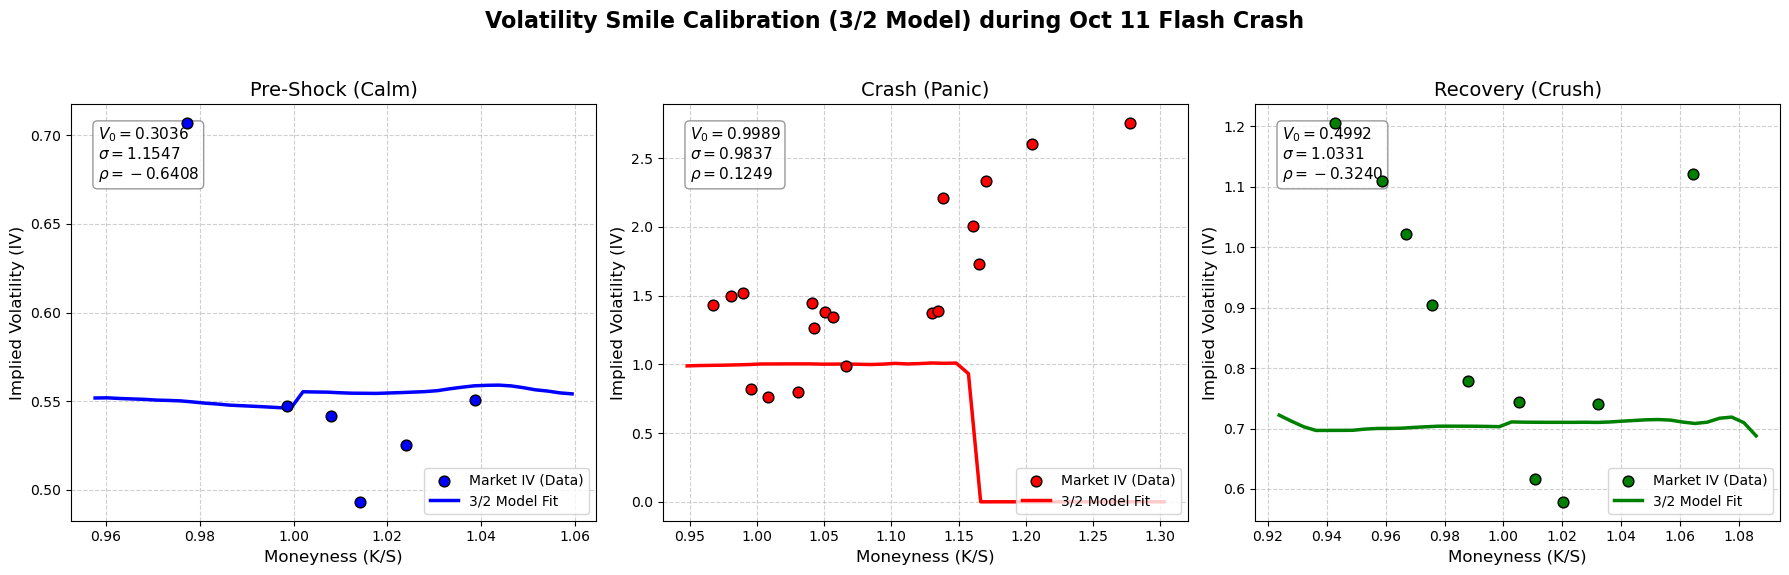

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq

# ==========================================
# 1. 基础工具：BS定价与隐含波动率反解器
# ==========================================
def bs_price_normalized(M, T, r, iv, opt_type):
    d1 = (np.log(1.0 / M) + (r + 0.5 * iv**2) * T) / (iv * np.sqrt(T))
    d2 = d1 - iv * np.sqrt(T)
    if opt_type == 'C':
        return norm.cdf(d1) - M * np.exp(-r * T) * norm.cdf(d2)
    else:
        return M * np.exp(-r * T) * norm.cdf(-d2) - norm.cdf(-d1)

def implied_vol_normalized(target_price, M, T, r, opt_type):
    """利用二分法(Brentq)反解 Black-Scholes 隐含波动率"""
    # 设定一个误差函数
    def objective(iv):
        return bs_price_normalized(M, T, r, iv, opt_type) - target_price
    try:
        # 在 1% 到 500% 的 IV 区间内寻找解
        return brentq(objective, 1e-4, 5.0)
    except ValueError:
        return np.nan # 如果模型价格极端导致无解，返回 NaN

# ==========================================
# 2. 3/2 模型定价器 (带固定随机种子以保证曲线平滑)
# ==========================================
def three_halves_mc_pricer_normalized(M_array, type_array, T, r, V0, kappa, theta, sigma, rho, Z_v_mat, Z_x_mat):
    num_paths, num_steps = Z_v_mat.shape
    dt = T / num_steps
    S = np.ones(num_paths)
    V = np.full(num_paths, V0)
    
    for i in range(num_steps):
        Z_v = Z_v_mat[:, i]
        Z_x = Z_x_mat[:, i]
        Z_s = rho * Z_v + np.sqrt(1.0 - rho**2) * Z_x
        V_pos = np.maximum(V, 1e-8) 
        S = S * np.exp((r - 0.5 * V_pos) * dt + np.sqrt(V_pos * dt) * Z_s)
        V = V + kappa * V_pos * (theta - V_pos) * dt + sigma * (V_pos**1.5) * np.sqrt(dt) * Z_v
        
    discount_factor = np.exp(-r * T)
    model_prices = np.zeros(len(M_array))
    
    for idx, (M, opt_type) in enumerate(zip(M_array, type_array)):
        payoff = np.maximum(S - M, 0.0) if opt_type == 'C' else np.maximum(M - S, 0.0)
        model_prices[idx] = np.mean(payoff) * discount_factor
        
    return model_prices

# ==========================================
# 3. 核心绘图逻辑
# ==========================================
def plot_volatility_smiles():
    # 你刚才拟合出的超棒参数！
    fixed_kappa = 2.2434
    fixed_theta = 0.0739
    
    results = {
        "1_Pre_Shock": {"file": "Deribit_OTM_Moneyness_1_Pre_Shock.csv", "V0": 0.3036, "sigma": 1.1547, "rho": -0.6408, "color": "blue", "title": "Pre-Shock (Calm)"},
        "2_Crash":     {"file": "Deribit_OTM_Moneyness_2_Crash.csv",     "V0": 0.9989, "sigma": 0.9837, "rho": 0.1249,  "color": "red",  "title": "Crash (Panic)"},
        "3_Recovery":  {"file": "Deribit_OTM_Moneyness_3_Recovery.csv",  "V0": 0.4992, "sigma": 1.0331, "rho": -0.3240, "color": "green","title": "Recovery (Crush)"}
    }
    
    # 设置画布 (1行3列)
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle("Volatility Smile Calibration (3/2 Model) during Oct 11 Flash Crash", fontsize=16, fontweight='bold')
    
    # 为了让画出来的曲线极致平滑，我们使用较高的路径数生成唯一的随机数矩阵
    np.random.seed(42)
    num_paths, num_steps = 50000, 30
    Z_v_mat = np.random.standard_normal((num_paths, num_steps))
    Z_x_mat = np.random.standard_normal((num_paths, num_steps))
    
    for ax, (phase, params) in zip(axes, results.items()):
        print(f"正在绘制 {phase} ...")
        
        # 1. 读取市场真实数据散点
        df = pd.read_csv(params["file"])
        market_M = df['Moneyness'].values
        market_IV = df['iv'].values / 100.0 if df['iv'].mean() > 5 else df['iv'].values
        T = df['T'].iloc[0]
        r = 0.0
        
        # 画出市场散点 (Market IV)
        ax.scatter(market_M, market_IV, color=params["color"], s=60, edgecolor='black', zorder=5, label='Market IV (Data)')
        
        # 2. 生成密集的网格用于绘制平滑的模型曲线
        # 网格范围稍微超过实际数据的边界，让曲线延伸一点
        m_min, m_max = market_M.min() * 0.98, market_M.max() * 1.02
        dense_M = np.linspace(m_min, m_max, 40)
        
        # 动态判断 OTM 类型: M < 1 是 Put, M >= 1 是 Call
        dense_type = np.where(dense_M < 1.0, 'P', 'C')
        
        # 计算 3/2 模型在这些密集点上的绝对价格
        model_prices = three_halves_mc_pricer_normalized(
            dense_M, dense_type, T, r, 
            params["V0"], fixed_kappa, fixed_theta, params["sigma"], params["rho"], 
            Z_v_mat, Z_x_mat
        )
        
        # 将模型绝对价格反解为 Model IV
        model_IVs = []
        for m, p, t_type in zip(dense_M, model_prices, dense_type):
            iv = implied_vol_normalized(p, m, T, r, t_type)
            model_IVs.append(iv)
            
        # 画出模型曲线 (Model IV)
        ax.plot(dense_M, model_IVs, color=params["color"], linewidth=2.5, linestyle='-', zorder=4, label='3/2 Model Fit')
        
        # 3. 图表美化与参数标注
        ax.set_title(params["title"], fontsize=14)
        ax.set_xlabel('Moneyness (K/S)', fontsize=12)
        ax.set_ylabel('Implied Volatility (IV)', fontsize=12)
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # 标注拟合参数的文本框
        textstr = '\n'.join((
            r'$V_0=%.4f$' % (params["V0"], ),
            r'$\sigma=%.4f$' % (params["sigma"], ),
            r'$\rho=%.4f$' % (params["rho"], )
        ))
        props = dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray')
        ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
                verticalalignment='top', bbox=props)
        
        ax.legend(loc='lower right')
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # 保存高清水印大图
    plt.savefig("Volatility_Smile_3Stages.png", dpi=300)
    print("绘制完成！图片已保存为 Volatility_Smile_3Stages.png")
    plt.show()

if __name__ == "__main__":
    plot_volatility_smiles()